In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

basedir = "../results"

/tmp/ipykernel_28832/2986688734.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


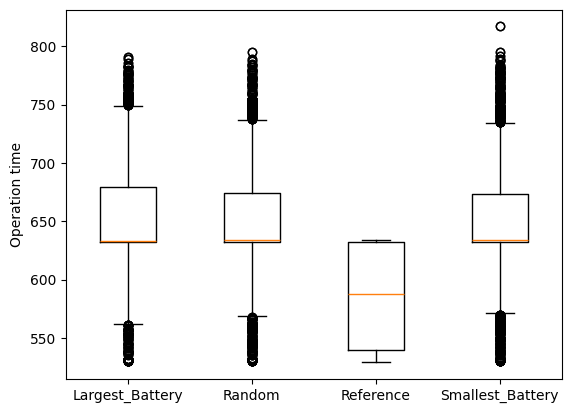

In [6]:
def plot_robot_average_operation_time(basedir):
    fig, ax1 = plt.subplots()
    labels = []
    data = {}

    tests = os.listdir(os.path.join(basedir, "0"))
    for t in tests:
        data[t] = []
    
    for dir in os.listdir(basedir):
        if not os.path.isdir(os.path.join(basedir, dir)):
            continue
        
        for t in tests:
            df = pd.read_csv(os.path.join(basedir, dir, t, 'simulation_stats.csv'))
            data[t].extend(df.filter(like='operation_time').sum().values)

    for key in data:
        data[key] = [int(x) for x in data[key]]

    ax1.boxplot(pd.DataFrame(data))
    ax1.set_ylabel("Operation time")
    ax1.set_xticklabels(tests)
    fig.show()
        
plot_robot_average_operation_time(basedir)